# Feature Engineering

## 1. Goal:
- Transform cleaned data into a feature set suitable for ML models
- Select and justify relevant features for prediction
- Encode categorical variables (e.g., one-hot, label encoding)
- Create additional useful features (e.g., text length, keyword-based features)
- Convert textual data into numerical representations
- Scale/normalize numerical features if needed
- Split dataset into training and test sets
- Produce a final feature matrix ready for modeling and implement the logic in `src/`

## 2. Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

## 3. Load Dataset

Load the raw dataset and verify shape before any transformations.

In [6]:
df = pd.read_csv("../data/processed/cleaned_job_postings.csv")

In [7]:
print(f"Shape: {df.shape}")
df.head()

Shape: (123545, 23)


,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,min_salary,...,remote_allowed,application_type,expiry,formatted_experience_level,listed_time,posting_domain,currency,normalized_salary,zip_code,fips
0,corcoran sawyer smith,marketing coordinator,job descriptiona leading real estate firm in n...,20.0,HOURLY,"princeton, nj",2774458.0,20.0,NaN,17.0,...,NaN,ComplexOnsiteApply,1.715990e+12,NaN,1.713398e+12,NaN,USD,38480.0,8540.0,34021.0
1,NaN,mental health therapist/counselor,"at aspen therapy and wellness , we are committ...",50.0,HOURLY,"fort collins, co",NaN,1.0,NaN,30.0,...,NaN,ComplexOnsiteApply,1.715450e+12,NaN,1.712858e+12,NaN,USD,83200.0,80521.0,8069.0
2,the national exemplar,assitant restaurant manager,the national exemplar is accepting application...,65000.0,YEARLY,"cincinnati, oh",64896719.0,8.0,NaN,45000.0,...,NaN,ComplexOnsiteApply,1.715870e+12,NaN,1.713278e+12,NaN,USD,55000.0,45202.0,39061.0
3,"abrams fensterman, llp",senior elder law / trusts and estates associat...,senior associate attorney - elder law / trusts...,175000.0,YEARLY,"new hyde park, ny",766262.0,16.0,NaN,140000.0,...,NaN,ComplexOnsiteApply,1.715488e+12,NaN,1.712896e+12,NaN,USD,157500.0,11040.0,36059.0
4,NaN,service technician,looking for hvac service tech with experience ...,80000.0,YEARLY,"burlington, ia",NaN,3.0,NaN,60000.0,...,NaN,ComplexOnsiteApply,1.716044e+12,NaN,1.713452e+12,NaN,USD,70000.0,52601.0,19057.0


## 4. Categorical Encoding (low cardinality)

Initialize the feature engineering dataframe as a copy of the cleaned data, so all transformations go into `df_fe` while `df` remains untouched.

In [8]:
df_fe = df.copy()
print(f"Feature engineering dataframe initialized: {df_fe.shape}")

Feature engineering dataframe initialized: (123545, 23)


Encoding strategy for low-cardinality categorical columns:

- `pay_period` - One-hot encoding (will be used in normalized salary calculation; missing values stay as all-zeros)
- `formatted_work_type` - One-hot encoding
- `application_type` - One-hot encoding
- `formatted_experience_level` - Ordinal encoding (natural hierarchy: Internship < Entry level < Associate < Mid-Senior level < Director < Executive)
- `currency` - Skipped here; used only in normalized salary calculation and removed in later steps

### 4.1 One-Hot Encoding


In [9]:
ohe_columns = ['pay_period', 'formatted_work_type', 'application_type']

for col in ohe_columns:
    dummies = pd.get_dummies(df_fe[col], prefix=col, dtype=int)
    df_fe = pd.concat([df_fe, dummies], axis=1)
    df_fe.drop(columns=[col], inplace=True)

print(f"Columns after one-hot encoding: {df_fe.shape[1]}")
print("New OHE columns:")
for col in ohe_columns:
    ohe_cols = [c for c in df_fe.columns if c.startswith(col + '_')]
    print(f"  {col}: {ohe_cols}")

Columns after one-hot encoding: 36
New OHE columns:
  pay_period: ['pay_period_BIWEEKLY', 'pay_period_HOURLY', 'pay_period_MONTHLY', 'pay_period_WEEKLY', 'pay_period_YEARLY']
  formatted_work_type: ['formatted_work_type_Contract', 'formatted_work_type_Full-time', 'formatted_work_type_Internship', 'formatted_work_type_Other', 'formatted_work_type_Part-time', 'formatted_work_type_Temporary', 'formatted_work_type_Volunteer']
  application_type: ['application_type_ComplexOnsiteApply', 'application_type_OffsiteApply', 'application_type_SimpleOnsiteApply', 'application_type_UnknownApply']


### 4.2 Ordinal Encoding: formatted_experience_level

In [10]:

experience_order = {
    'Internship':        0,
    'Entry level':       1,
    'Associate':         2,
    'Mid-Senior level':  2,
    'Director':          4,
    'Executive':         4
}

df['experience_level_ord'] = df['formatted_experience_level'].map(experience_order)

print("Ordinal mapping applied:")
for level, code in experience_order.items():
    count = (df['experience_level_ord'] == code).sum()
    print(f"  {code} = {level} ({count:,} rows)")

missing = df['experience_level_ord'].isna().sum()
print(f"  NaN = missing ({missing:,} rows)")

df.drop(columns=['formatted_experience_level'], inplace=True)

Ordinal mapping applied:
  0 = Internship (1,441 rows)
  1 = Entry level (36,561 rows)
  2 = Associate (51,230 rows)
  2 = Mid-Senior level (51,230 rows)
  4 = Director (4,968 rows)
  4 = Executive (4,968 rows)
  NaN = missing (29,345 rows)


### Encoding summary

| Column | Method | Notes |
|--------|--------|-------|
| `pay_period` | One-hot | NaN rows get all-zero dummy columns; used in salary normalization |
| `formatted_work_type` | One-hot | No missing values |
| `application_type` | One-hot | No missing values |
| `formatted_experience_level` | Ordinal (0-5) | Natural rank order; NaN preserved for later imputation |
| `currency` | No encoding | Temporary helper for salary normalization; dropped later |

## 5. Text Feature Engineering


### 5.1 Salary Extraction and Normalization

This subsection extracts numerical pay structures from the unstructured text descriptions. It handles ranges by taking their midpoint, maps unique localized pay frequencies (`hourly`, `daily`, `yearly`), ignores false-positive features like `401(k)` options, and annualizes rates dynamically to build a standardized numerical tracking feature.

In [23]:
def clean_and_parse_number(num_str):
    """Removes currency symbols and converts string numbers to floats."""
    if not num_str:
        return np.nan
    clean_str = re.sub(r'[\$,\s]', '', num_str)
    try:
        return float(clean_str)
    except ValueError:
        return np.nan

def determine_period(match_text):
    """Detects the pay period from the text block context."""
    text = match_text.lower()
    if any(p in text for p in ['hour', 'hr', 'hourly', '/hr']):
        return 'hourly'
    if any(p in text for p in ['day', 'daily', '/day']):
        return 'daily'
    if any(p in text for p in ['year', 'yr', 'annual', 'annually', 'salary', 'compensation', '/yr']):
        return 'yearly'
    return 'unknown'

def annualize_amount(amount, period):
    """Normalizes an amount to a yearly scale based on its specific period."""
    if not amount or period == 'unknown' or not period:
        return np.nan
    if period == 'hourly':
        return amount * 40 * 52  # Standard 2,080 hour work year
    if period == 'daily':
        return amount * 5 * 52   # Standard 260 day work year
    return amount                # Already yearly

def extract_salary_from_description(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0

    # Base regex patterns protecting against 401k variations using negative lookahead
    money_num = r'\d{1,3}(?:,\d{3})*(?:\.\d{2})?(?!\s*k\b)'
    money_pattern = rf'\$\s*{money_num}(?:\s*(?:-|–|to)\s*\$?\s*{money_num})?'
    
    keywords = r'(?:pay(?:| range)?|salary|wage|hourly rate|compensation|starting at|from)'
    timeframes = r'(?:hour|hr|hourly|year|yr|annually|per year|annual salary|one day|day|daily)'

    patterns = [
        rf'{keywords}\s*[:\-–]?\s*(?:from\s*)?({money_pattern}(?:\s*(?:/|per\s*)?{timeframes})?)',
        rf'({money_pattern}\s*(?:/|per\s*)?{timeframes})',
        rf'({money_pattern})' 
    ]
    
    master_regex = re.compile('|'.join(patterns), re.IGNORECASE)
    annualized_candidates = []

    for match_obj in master_regex.finditer(text):
        clean_match = next((g.strip() for g in match_obj.groups() if g), "")
        if not clean_match:
            continue
            
        numbers = re.findall(r'\$?(\d{1,3}(?:,\d{3})*(?:\.\d{2})?)(?!\s*k\b)', clean_match)
        parsed_vals = [clean_and_parse_number(n) for n in numbers if clean_and_parse_number(n) is not None]
        
        if parsed_vals:
            # Gather localized text window context for this specific snippet
            start_idx = max(0, match_obj.start() - 15)
            end_idx = min(len(text), match_obj.end() + 15)
            context_window = text[start_idx:end_idx]
            
            match_period = determine_period(context_window)
            
            # Use the average/midpoint if a range is provided
            match_base_value = sum(parsed_vals) / len(parsed_vals)
            match_annualized = round(annualize_amount(match_base_value, match_period), 2)
            
            if match_annualized > 0:
                annualized_candidates.append((match_annualized, match_period))

    if annualized_candidates:
        # Prioritize matching explicitly stated yearly schedules over fallback equivalents
        yearly_options = [c for c in annualized_candidates if c[1] == 'yearly']
        best_candidate = yearly_options[0] if yearly_options else annualized_candidates[0]
        return best_candidate[0]

    return 0.0

In [ ]:
df_fe["extracted_salary"] = df_fe["description"].apply(extract_salary_from_description)

,description,extracted_salary
0,job descriptiona leading real estate firm in n...,39520.0
1,"at aspen therapy and wellness , we are committ...",62400.0
2,the national exemplar is accepting application...,0.0
3,senior associate attorney - elder law / trusts...,157500.0
4,looking for hvac service tech with experience ...,0.0


In [13]:
df_fe[['normalized_salary', "extracted_salary"]].head()

,normalized_salary,extracted_salary
0,38480.0,39520.0
1,83200.0,62400.0
2,55000.0,0.0
3,157500.0,157500.0
4,70000.0,0.0


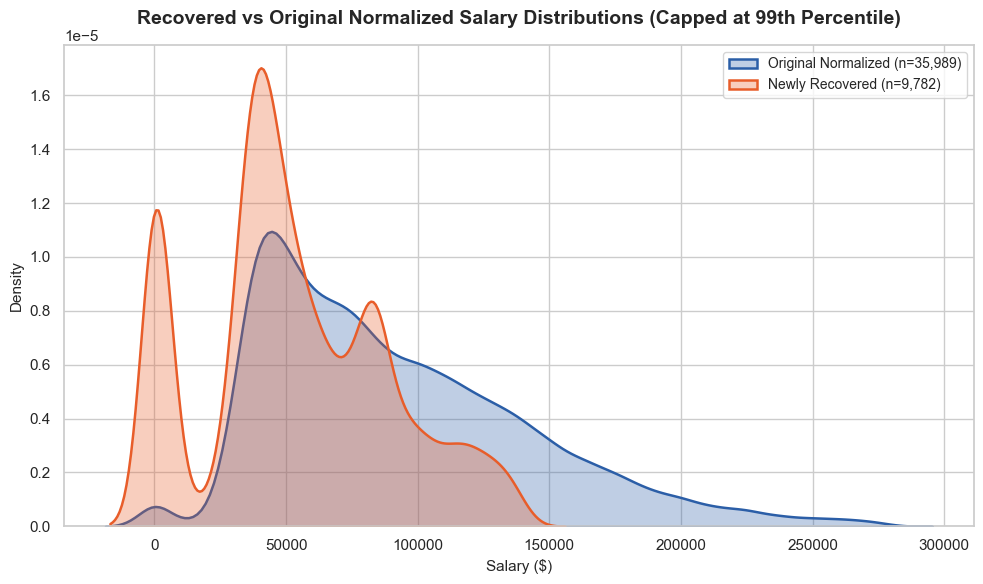

Newly Recovered Salaries: 9,782
Estimated Missing After Imputation: 77,774 (63.0%)


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Preparation (from extraction/comparison cell) ---

# Cap extracted salaries at the 97th percentile
valid_extracted = df_fe.loc[df_fe["extracted_salary"] > 0, "extracted_salary"]
if not valid_extracted.empty:
    percentile_99 = np.percentile(valid_extracted, 97)
    df_fe.loc[df_fe["extracted_salary"] > percentile_99, "extracted_salary"] = np.nan

# Identify newly recovered salaries
is_normalized_missing = df_fe["normalized_salary"].isna() | (df_fe["normalized_salary"] == 0)
is_extracted_present = df_fe["extracted_salary"].notna() & (df_fe["extracted_salary"] > 0)
newly_recovered_df = df_fe[is_normalized_missing & is_extracted_present].copy()

# --- Visualization ---

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

recovered_salaries = newly_recovered_df["extracted_salary"].dropna()
recovered_salaries = recovered_salaries[recovered_salaries > 0]

original_normalized = df_fe.loc[
    (df_fe["normalized_salary"].notna()) & (df_fe["normalized_salary"] > 0),
    "normalized_salary"
]

if not recovered_salaries.empty and not original_normalized.empty:
    combined_cap = np.percentile(
        np.concatenate([original_normalized.values, recovered_salaries.values]),
        99
    )
    norm_capped = original_normalized[original_normalized <= combined_cap]
    recov_capped = recovered_salaries[recovered_salaries <= combined_cap]

    sns.kdeplot(norm_capped, ax=ax, color="#2B5EA7", fill=True, alpha=0.3,
                linewidth=1.8, label=f"Original Normalized (n={len(original_normalized):,})")
    sns.kdeplot(recov_capped, ax=ax, color="#E85D2A", fill=True, alpha=0.3,
                linewidth=1.8, label=f"Newly Recovered (n={len(recovered_salaries):,})")

    ax.set_xlabel("Salary ($)", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.legend(fontsize=10)

ax.set_title("Recovered vs Original Normalized Salary Distributions (Capped at 99th Percentile)",
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

# --- Post-imputation missing stats ---
total_rows = len(df_fe)
newly_recovered_count = len(recovered_salaries)
missing_before = is_normalized_missing.sum()
missing_after = missing_before - newly_recovered_count
missing_pct_after = (missing_after / total_rows) * 100

print(f"Newly Recovered Salaries: {newly_recovered_count:,}")
print(f"Estimated Missing After Imputation: {missing_after:,} ({missing_pct_after:.1f}%)")

- **9,782 new salary values** recovered from unstructured text, but at least **77,774 (63.0%)** will still be missing after imputation
- Recovered salaries skew lower, clustering around **$30,000–$50,000** (likely from annualized hourly/daily rates)
- Visible spike near **$0** indicates false extractions (e.g., benefit descriptions, formatting artifacts) that need cleaning
- Plot is capped at the 99th percentile; upper-end outliers still exist in raw data and will be handled in later steps